In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style
import seaborn as sns

In [2]:
df = pd.read_csv("../data/train.csv")
df

,id,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,Designation,MonthlyIncome,customer_info,ProdTaken
0,0,50歳,Self Enquiry,2,900秒,Large Business,male,1.0,4.0,Basic,3.0,5,1,4,Executive,253905.0,未婚 車未所持 子供なし,1
1,1,56歳,Company Invited,1,14分,Salaried,Male,1.0,4.0,Standard,3.0,2,1,4,Senior Manager,404475.0,"離婚済み,車あり,子供無し",0
2,2,NaN,Self Enquiry,1,10分,Large Business,Female,1.0,3.0,Basic,3.0,4,0,4,Executive,278145.0,"結婚済み、自動車未所有,子供なし",1
3,3,三十七歳,Self Enquiry,2,1080秒,Small Business,female,1.0,3.0,Standard,4.0,1,0,5,Senior Manager,326805.0,離婚済み、車所持、子供無し,0
4,4,48歳,Company Invited,3,1020秒,Small Business,female,1.0,3.0,Basic,4.0,4,0,4,Executive,258435.0,独身／車所持／無子,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3484,3484,40歳,Self Enquiry,2,1560秒,Salaried,Male,2.0,3.0,Basic,3.0,3,0,1,Executive,258900.0,離婚済み 乗用車所持 子供なし,1
3485,3485,40代,Self Enquiry,1,9分,Large Business,Male,3.0,3.0,Basic,5.0,5,0,3,Executive,260415.0,結婚済み、車所持、子供2人,0
3486,3486,31歳,Self Enquiry,1,840秒,Small Business,FEMALE,3.0,2.0,Standard,3.0,5,0,4,Senior Manager,317340.0,独身／車所持／こども1人,0
3487,3487,56歳,Company Invited,2,900秒,Salaried,Male,3.0,6.0,King,3.0,7,1,4,VP,527910.0,結婚済み、自動車未所有、子供2人,1


In [3]:
df["TypeofContact"].value_counts()
df = df.dropna(subset=['TypeofContact'])#欠損値削除(6件)

In [4]:
pd.unique(df['TypeofContact'].values.ravel())

<StringArray>
['Self Enquiry', 'Company Invited']
Length: 2, dtype: str

## その顧客と最初にどのような形で接触（コンタクト）したか

* 'Self Enquiry':　顧客自ら問い合わせしてきた2194件
* 'Company Invited' :　会社側からアプローチした1289件
* 記載なし6件

In [5]:
df["TypeofContact"].value_counts()

TypeofContact
Self Enquiry       2194
Company Invited    1289
Name: count, dtype: int64

In [6]:
df["TypeofContact"]

0          Self Enquiry
1       Company Invited
2          Self Enquiry
3          Self Enquiry
4       Company Invited
             ...       
3484       Self Enquiry
3485       Self Enquiry
3486       Self Enquiry
3487    Company Invited
3488       Self Enquiry
Name: TypeofContact, Length: 3483, dtype: str

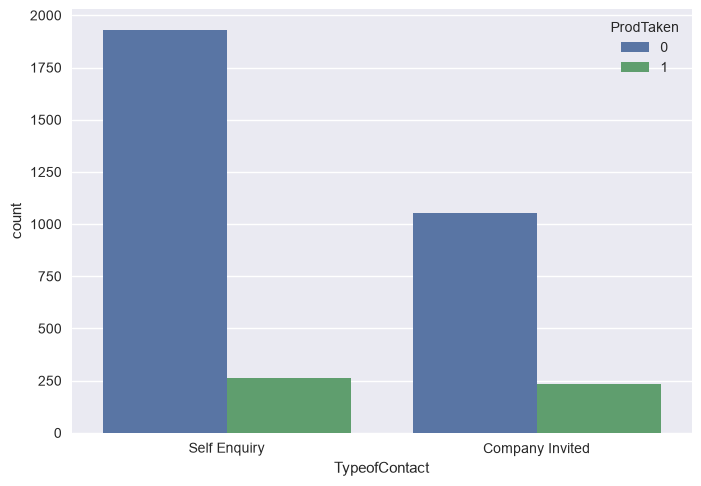

In [7]:
matplotlib.style.use("seaborn-v0_8")
sns.countplot(data=df, x='TypeofContact', hue='ProdTaken')

plt.show()

'Self Enquiry':　顧客自ら問い合わせしてきた2194件

'Company Invited' :　会社側からアプローチした1289件

記載なし6件

<Axes: xlabel='TypeofContact', ylabel='Count'>

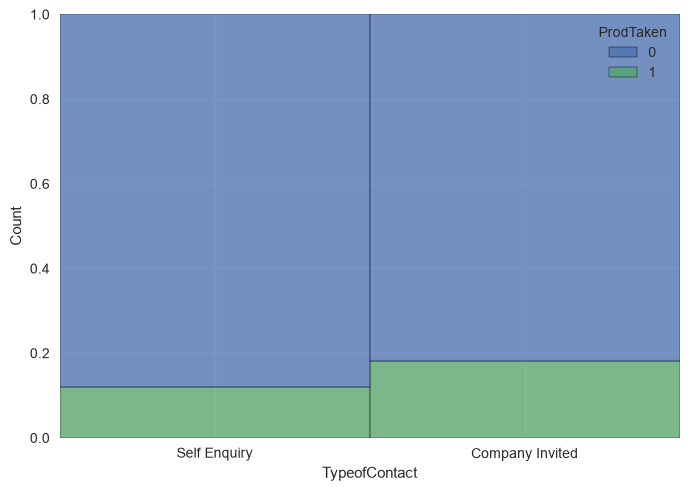

In [8]:
sns.histplot(data=df, x='TypeofContact', hue='ProdTaken', multiple='fill')

顧客から問い合わせしてきて成約した割合と<br>
会社側で営業して成約した割合の比較<br>
なぜか営業したほうが成約率が高い<br>
興味があって問い合わせしてきたはずなのに<br>
値段が合わなかったのかサービスが思った通りではなかったのか<br>
でもここで営業をかけた方が成約率がかなり高いことがわかる<br>

### ０/１に変換する

0: 顧客自ら問い合わせしてきたSelf Enquiry<br>
1: 会社側からアプローチしたCompany Invited

In [9]:
df["TypeofContact"]

0          Self Enquiry
1       Company Invited
2          Self Enquiry
3          Self Enquiry
4       Company Invited
             ...       
3484       Self Enquiry
3485       Self Enquiry
3486       Self Enquiry
3487    Company Invited
3488       Self Enquiry
Name: TypeofContact, Length: 3483, dtype: str

In [10]:
df['TypeofContact'] = df['TypeofContact'].map({'Self Enquiry': 0, 'Company Invited': 1})

In [11]:
df["TypeofContact"]

0       0
1       1
2       0
3       0
4       1
       ..
3484    0
3485    0
3486    0
3487    1
3488    0
Name: TypeofContact, Length: 3483, dtype: int64

In [13]:
"""
df['TypeofContact'] = df['TypeofContact'].map({'Self Enquiry': 0, 'Company Invited': 1})
df = df.dropna(subset=['TypeofContact'])#欠損値削除(6件)
"""

"\ndf['TypeofContact'] = df['TypeofContact'].map({'Self Enquiry': 0, 'Company Invited': 1})\ndf = df.dropna(subset=['TypeofContact'])#欠損値削除(6件)\n"